**Setup**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import importlib.util
import sys

spec  = importlib.util.spec_from_file_location("utils", "/content/drive/MyDrive/ML_aircraft_recognition/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["utils"] = utils
spec.loader.exec_module(utils)

from utils import load_dataset, get_dataloaders, load_model, load_resnet

import torch
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Using device: cuda


**Load models**

In [2]:
dataset = load_dataset()
_, _, _, num_classes, _, _, _ = get_dataloaders(dataset)

model_eff = load_model(num_classes, device)
model_res = load_resnet(num_classes, device)
print("Both models loaded!")

 100% |███████████████| 3334/3334 [1.2s elapsed, 0s remaining, 2.8K samples/s]         


INFO:eta.core.utils: 100% |███████████████| 3334/3334 [1.2s elapsed, 0s remaining, 2.8K samples/s]         


Loaded 3334 samples
Train: 2333 | Val: 500 | Test: 501 | Classes: 100
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 183MB/s]


Model loaded from /content/drive/MyDrive/ML_aircraft_recognition/best_model.pth
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


ResNet loaded from /content/drive/MyDrive/ML_aircraft_recognition/best_resnet.pth
Both models loaded!


**Label mapping**

In [3]:
label_names = sorted(dataset.distinct("ground_truth.label"))
print(f"{len(label_names)} classes loaded")

100 classes loaded


**Inference function**

In [4]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict(image_path, models, label_names, device, top_k=5):
    img = Image.open(image_path).convert("RGB")
    tensor = inference_transform(img).unsqueeze(0).to(device)

    probs = torch.zeros(1, len(label_names)).to(device)
    for model in models:
        model.eval()
        with torch.no_grad():
            probs += torch.softmax(model(tensor), dim=1)
    probs /= len(models)

    top_probs, top_indices = probs.topk(top_k, dim=1)
    top_probs   = top_probs.squeeze().cpu().numpy()
    top_indices = top_indices.squeeze().cpu().numpy()

    results = [(label_names[i], float(p)) for i, p in zip(top_indices, top_probs)]
    return img, results

**Upload and predict**

Saving F-16.jpg to F-16.jpg


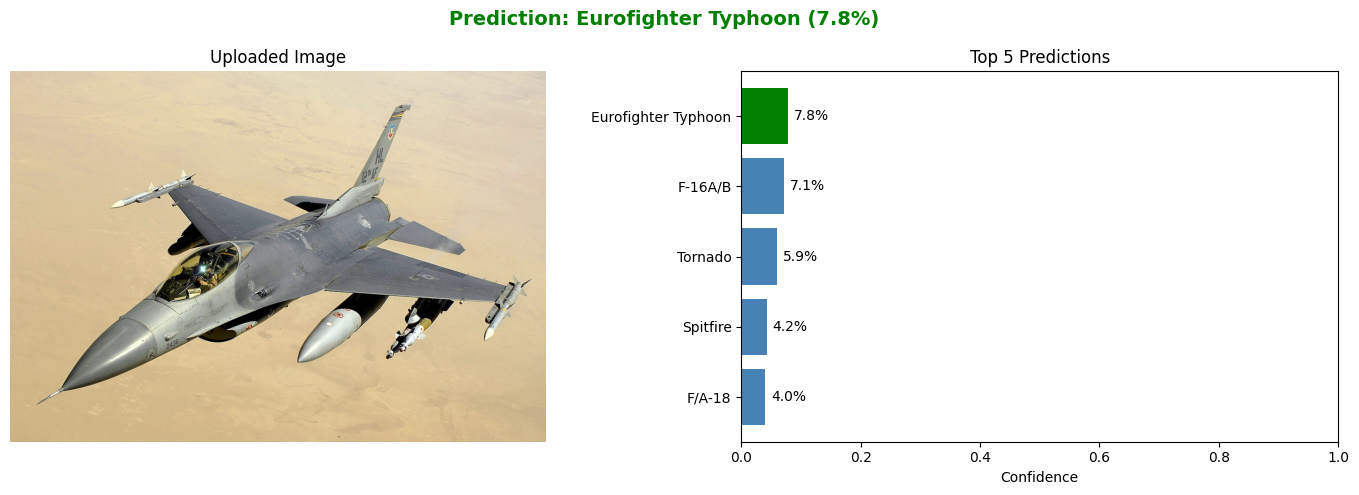


Top 5 predictions:
  1. Eurofighter Typhoon: 7.8%
  2. F-16A/B: 7.1%
  3. Tornado: 5.9%
  4. Spitfire: 4.2%
  5. F/A-18: 4.0%


In [6]:
from google.colab import files

uploaded = files.upload()  # opens file picker
image_path = list(uploaded.keys())[0]

img, results = predict(image_path, [model_eff, model_res], label_names, device)

# Display image with predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img)
axes[0].set_title("Uploaded Image")
axes[0].axis("off")

labels  = [r[0] for r in results]
scores  = [r[1] for r in results]
colors  = ["steelblue"] * len(labels)
colors[0] = "green"  # highlight top prediction

axes[1].barh(labels[::-1], scores[::-1], color=colors[::-1])
axes[1].set_title("Top 5 Predictions")
axes[1].set_xlabel("Confidence")
axes[1].set_xlim(0, 1)

for i, (label, score) in enumerate(zip(labels[::-1], scores[::-1])):
    axes[1].text(score + 0.01, i, f"{score*100:.1f}%", va="center")

plt.suptitle(f"Prediction: {results[0][0]} ({results[0][1]*100:.1f}%)",
             fontsize=14, fontweight="bold", color="green")
plt.tight_layout()
plt.show()

print(f"\nTop 5 predictions:")
for i, (label, prob) in enumerate(results, 1):
    print(f"  {i}. {label}: {prob*100:.1f}%")